In [72]:
!pip install -q grad-cam

import os
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
import torchvision.models as models

from torchvision.models import (
    VGG16_Weights,
    ResNet50_Weights
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix
)

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [73]:
from google.colab import drive
drive.mount('/content/drive')

print(os.listdir('/content/drive/MyDrive/Tomato_Leaf_Disease'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['train', 'test']


In [74]:
DATASET_ROOT = "/content/drive/MyDrive/Tomato_Leaf_Disease"

TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
TEST_DIR  = os.path.join(DATASET_ROOT, "test")

for d in os.listdir(TEST_DIR):
    print(d, "->", len(os.listdir(os.path.join(TEST_DIR, d))))

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
LR = 0.0001

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Tomato___Tomato_Yellow_Leaf_Curl_Virus -> 0
Tomato___Tomato_mosaic_virus -> 200
Tomato___Septoria_leaf_spot -> 355
Tomato___Target_Spot -> 0
Tomato___Spider_mites Two-spotted_spider_mite -> 0
Tomato___Leaf_Mold -> 0
Tomato___Late_blight -> 0
Tomato___healthy -> 0
Tomato___Bacterial_spot -> 0
Tomato___Early_blight -> 0
Using device: cuda


In [75]:
SEVERITY_MAP = {
    "Tomato___healthy": 0.0,
    "Tomato___Tomato_mosaic_virus": 2.5,
    "Tomato___Septoria_leaf_spot": 4.0,
    "Tomato___Leaf_Mold": 4.5,
    "Tomato___Spider_mites Two-spotted_spider_mite": 5.0,
    "Tomato___Target_Spot": 5.5,
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus": 6.5,
    "Tomato___Bacterial_spot": 7.0,
    "Tomato___Early_blight": 7.5,
    "Tomato___Late_blight": 10.0
}
CLASSES = sorted([
    d for d in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, d))
    and not d.startswith(".")
])
NUM_CLASSES = len(CLASSES)

CLASS_TO_IDX = {
    c:i for i,c in enumerate(CLASSES)
}

In [76]:
class TomatoDataset(Dataset):

    def __init__(self, root, transform=None):

        self.samples = []
        self.transform = transform

        for cls_name in os.listdir(root):

            cls_path = os.path.join(root, cls_name)

            if not os.path.isdir(cls_path):
                continue

            label = CLASS_TO_IDX[cls_name]
            severity = SEVERITY_MAP.get(cls_name, 5.0)

            for file in os.listdir(cls_path):

                if file.lower().endswith((".jpg", ".jpeg", ".png")):

                    path = os.path.join(cls_path, file)

                    self.samples.append(
                        (path, label, severity)
                    )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        path, label, severity = self.samples[idx]

        image = Image.open(path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label, torch.tensor(severity).float()

In [77]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

train_dataset = TomatoDataset(TRAIN_DIR, transform)
test_dataset  = TomatoDataset(TEST_DIR, transform)
print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

print("Classes:")
print(CLASSES)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Train samples: 7396
Test samples: 555
Classes:
['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


In [79]:
class DualModel(nn.Module):

    def __init__(self, backbone="vgg16"):

        super().__init__()

        self.backbone_name = backbone

        # VGG16
        if backbone == "vgg16":

            base = models.vgg16(
                weights=VGG16_Weights.IMAGENET1K_V1
            )

            self.features = base.features
            self.avgpool = base.avgpool

            self.shared = nn.Sequential(
                nn.Flatten(),
                *list(base.classifier.children())[:-1]
            )

            feature_dim = 4096

        # ---------------------
        # ResNet50
        # ---------------------
        else:

            base = models.resnet50(
                weights=ResNet50_Weights.IMAGENET1K_V1
            )

            self.features = nn.Sequential(
                *list(base.children())[:-2]
            )

            self.avgpool = base.avgpool

            self.shared = nn.Flatten()

            feature_dim = 2048

        # Classification Head
        self.classifier = nn.Linear(
            feature_dim,
            NUM_CLASSES
        )

        # Regression Head
        self.regressor = nn.Linear(
            feature_dim,
            1
        )

    def forward(self, x):

        x = self.features(x)
        x = self.avgpool(x)
        x = self.shared(x)

        cls_output = self.classifier(x)

        reg_output = self.regressor(x).squeeze(1)

        return cls_output, reg_output

    # Grad-CAM Layer
    def get_cam_layer(self):

        if self.backbone_name == "vgg16":
            return self.features[-1]

        return self.features[-1][-1].conv3

In [80]:
def train_model(backbone):

    print(f"\nTraining {backbone.upper()}")

    model = DualModel(backbone).to(DEVICE)

    cls_loss_fn = nn.CrossEntropyLoss()
    reg_loss_fn = nn.MSELoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=LR
    )

    best_f1 = 0
    best_weights = None

    for epoch in range(EPOCHS):

        # ---------------------
        # Training
        # ---------------------
        model.train()

        for images, labels, severity in train_loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            severity = severity.to(DEVICE)

            optimizer.zero_grad()

            cls_out, reg_out = model(images)

            cls_loss = cls_loss_fn(cls_out, labels)

            reg_loss = reg_loss_fn(reg_out, severity)

            loss = cls_loss + 0.3 * reg_loss

            loss.backward()
            optimizer.step()

        # ---------------------
        # Evaluation
        # ---------------------
        model.eval()

        all_preds = []
        all_labels = []

        reg_preds = []
        reg_true = []

        with torch.no_grad():

            for images, labels, severity in test_loader:

                images = images.to(DEVICE)
                labels = labels.to(DEVICE)
                severity = severity.to(DEVICE)

                cls_out, reg_out = model(images)

                preds = torch.argmax(cls_out, dim=1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

                reg_preds.extend(reg_out.cpu().numpy())
                reg_true.extend(severity.cpu().numpy())

        acc = accuracy_score(all_labels, all_preds)

        f1 = f1_score(all_labels, all_preds, average="weighted")

        mse = np.mean(
            (np.array(reg_preds) - np.array(reg_true)) ** 2
        )

        print(
            f"Epoch {epoch+1}/{EPOCHS} | "
            f"Accuracy: {acc:.4f} | "
            f"F1: {f1:.4f} | "
            f"MSE: {mse:.4f}"
        )

        if f1 > best_f1:
            best_f1 = f1
            best_weights = copy.deepcopy(model.state_dict())


    if best_weights is not None:
        model.load_state_dict(best_weights)
    else:
        print("No best weights found.")

    return model

In [81]:
vgg_model = train_model("vgg16")

resnet_model = train_model("resnet50")


Training VGG16
Epoch 1/10 | Accuracy: 0.3568 | F1: 0.3382 | MSE: 4.0609
Epoch 2/10 | Accuracy: 0.3477 | F1: 0.3477 | MSE: 4.3241
Epoch 3/10 | Accuracy: 0.3604 | F1: 0.3376 | MSE: 4.4764
Epoch 4/10 | Accuracy: 0.3604 | F1: 0.3448 | MSE: 4.9846
Epoch 5/10 | Accuracy: 0.3604 | F1: 0.3261 | MSE: 3.3288
Epoch 6/10 | Accuracy: 0.3604 | F1: 0.3516 | MSE: 4.5178
Epoch 7/10 | Accuracy: 0.3604 | F1: 0.3440 | MSE: 3.7891
Epoch 8/10 | Accuracy: 0.3604 | F1: 0.3344 | MSE: 4.1507
Epoch 9/10 | Accuracy: 0.3604 | F1: 0.3448 | MSE: 3.6841
Epoch 10/10 | Accuracy: 0.3604 | F1: 0.3424 | MSE: 6.1441

Training RESNET50
Epoch 1/10 | Accuracy: 0.3586 | F1: 0.3586 | MSE: 5.4698
Epoch 2/10 | Accuracy: 0.3604 | F1: 0.3499 | MSE: 4.9964
Epoch 3/10 | Accuracy: 0.3604 | F1: 0.3490 | MSE: 5.3612
Epoch 4/10 | Accuracy: 0.3604 | F1: 0.3432 | MSE: 3.7680
Epoch 5/10 | Accuracy: 0.3604 | F1: 0.3542 | MSE: 4.3022
Epoch 6/10 | Accuracy: 0.3604 | F1: 0.3533 | MSE: 5.0678
Epoch 7/10 | Accuracy: 0.3604 | F1: 0.3499 | MSE: 4.

In [82]:
def evaluate_model(model):

    model.eval()

    all_preds = []
    all_labels = []

    reg_preds = []
    reg_true = []

    with torch.no_grad():

        for images, labels, severity in test_loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            severity = severity.to(DEVICE)

            cls_out, reg_out = model(images)

            preds = torch.argmax(
                cls_out,
                dim=1
            )

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

            reg_preds.extend(
                reg_out.cpu().numpy()
            )

            reg_true.extend(
                severity.cpu().numpy()
            )

    acc = accuracy_score(
        all_labels,
        all_preds
    )

    f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted"
    )

    mse = np.mean(
        (
            np.array(reg_preds) -
            np.array(reg_true)
        ) ** 2
    )

    return {
        "accuracy": acc,
        "f1": f1,
        "mse": mse,
        "labels": all_labels,
        "preds": all_preds
    }


In [83]:
vgg_metrics = evaluate_model(vgg_model)

resnet_metrics = evaluate_model(resnet_model)

print("\nVGG16")
print(vgg_metrics)

print("\nResNet50")
print(resnet_metrics)
print("VGG labels:", len(vgg_metrics["labels"]))
print("VGG preds:", len(vgg_metrics["preds"]))

print("ResNet labels:", len(resnet_metrics["labels"]))
print("ResNet preds:", len(resnet_metrics["preds"]))


VGG16
{'accuracy': 0.36036036036036034, 'f1': 0.35157108327840036, 'mse': np.float32(4.517764), 'labels': [np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64

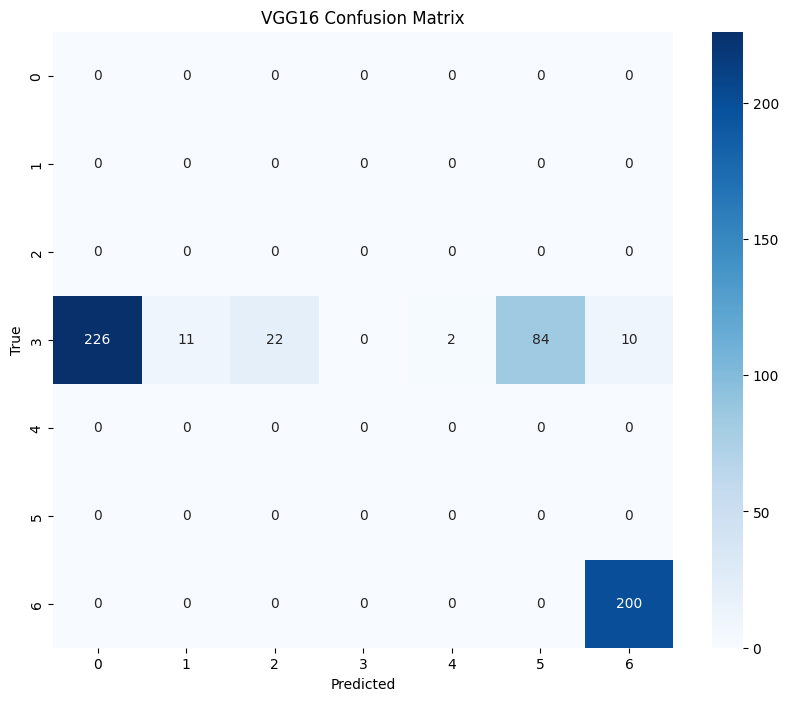

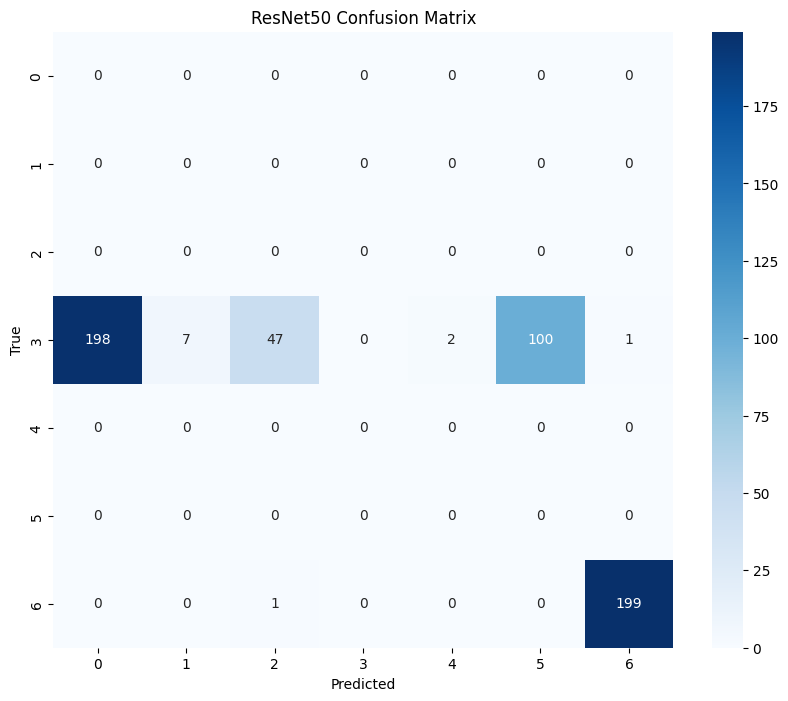

In [84]:
def plot_confusion(metrics, title):

    cm = confusion_matrix(
        metrics["labels"],
        metrics["preds"]
    )

    plt.figure(figsize=(10,8))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(title)

    plt.xlabel("Predicted")
    plt.ylabel("True")

    plt.show()

plot_confusion(
    vgg_metrics,
    "VGG16 Confusion Matrix"
)

plot_confusion(
    resnet_metrics,
    "ResNet50 Confusion Matrix"
)


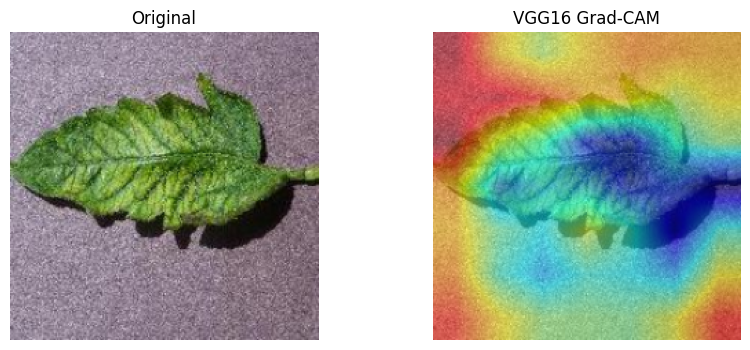

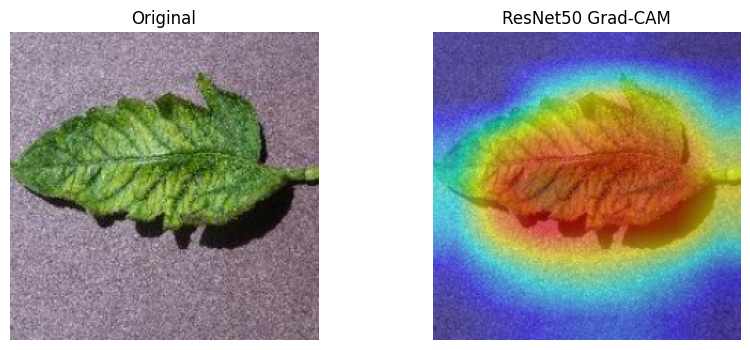

In [85]:
class Wrapper(nn.Module):

    def __init__(self, model):

        super().__init__()

        self.model = model

    def forward(self, x):

        cls_out, _ = self.model(x)

        return cls_out

def run_gradcam(model, title):

    wrapped = Wrapper(model)

    cam = GradCAM(
        model=wrapped,
        target_layers=[model.get_cam_layer()]
    )

    image, label, severity = test_dataset[0]

    input_tensor = image.unsqueeze(0).to(DEVICE)

    cls_out, _ = model(input_tensor)

    pred = torch.argmax(
        cls_out,
        dim=1
    ).item()

    targets = [
        ClassifierOutputTarget(pred)
    ]

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )[0]

    rgb_img = image.permute(
        1,2,0
    ).numpy()

    cam_image = show_cam_on_image(
        rgb_img,
        grayscale_cam,
        use_rgb=True
    )

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(rgb_img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(cam_image)
    plt.title(title)
    plt.axis("off")

    plt.show()

run_gradcam(vgg_model, "VGG16 Grad-CAM")

run_gradcam(resnet_model, "ResNet50 Grad-CAM")


In [86]:
summary = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "F1 Score",
        "MSE"
    ],

    "VGG16": [
        round(vgg_metrics["accuracy"], 4),
        round(vgg_metrics["f1"], 4),
        round(vgg_metrics["mse"], 4)
    ],

    "ResNet50": [
        round(resnet_metrics["accuracy"], 4),
        round(resnet_metrics["f1"], 4),
        round(resnet_metrics["mse"], 4)
    ]
})

print("\nFinal Comparison Table\n")

print(summary)



Final Comparison Table

     Metric   VGG16  ResNet50
0  Accuracy  0.3604    0.3586
1  F1 Score  0.3516    0.3586
2       MSE  4.5178    5.4698


In [87]:
torch.save(
    vgg_model.state_dict(),
    "vgg16_model.pth"
)

torch.save(
    resnet_model.state_dict(),
    "resnet50_model.pth"
)

print("\nModels Saved")


Models Saved
